# Notebook 05 — Ensemble & Stacking

This notebook compares individual models against two ensemble strategies:
- **Soft Voting** – averages class probabilities from LR, MLP, and XGBoost.
- **Stacking** – trains a logistic-regression meta-learner on out-of-fold predictions from the same three base learners.

Aim: determine whether combining learners overcomes the individual accuracy ceiling.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from src.data import load_features, CLASSES
from src.evaluation import make_skf

In [2]:
X_train, y_train = load_features("../data/train_energy_data.csv", "core")
X_test,  y_test  = load_features("../data/test_energy_data.csv",  "core")
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (1000, 2)  Test: (100, 2)


## Base learners

In [3]:
lr = make_pipeline(StandardScaler(),
                   LogisticRegression(C=10, max_iter=1000, random_state=42))

mlp = make_pipeline(StandardScaler(),
                    MLPClassifier(hidden_layer_sizes=(20,20), activation="relu",
                                  alpha=0.01, max_iter=500, random_state=42))

xgb = XGBClassifier(max_depth=3, learning_rate=0.05, n_estimators=100,
                    objective="multi:softprob", num_class=3,
                    eval_metric="mlogloss", verbosity=0, random_state=42)

## Ensemble models

In [4]:
voting = VotingClassifier(
    estimators=[("lr", lr), ("mlp", mlp), ("xgb", xgb)],
    voting="soft",
)

stacking = StackingClassifier(
    estimators=[("lr", lr), ("mlp", mlp), ("xgb", xgb)],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=1,
)

## 5-fold CV comparison

In [5]:
skf = make_skf()

named = [
    ("LR",       lr),
    ("MLP",      mlp),
    ("XGBoost",  xgb),
    ("Voting",   voting),
    ("Stacking", stacking),
]

results = {}
for name, model in named:
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")
    results[name] = scores
    print(f"{name:10s}  CV={scores.mean():.3f} ± {scores.std():.3f}")


LR          CV=0.626 ± 0.017
MLP         CV=0.631 ± 0.017
XGBoost     CV=0.582 ± 0.038
Voting      CV=0.625 ± 0.026
Stacking    CV=0.628 ± 0.015


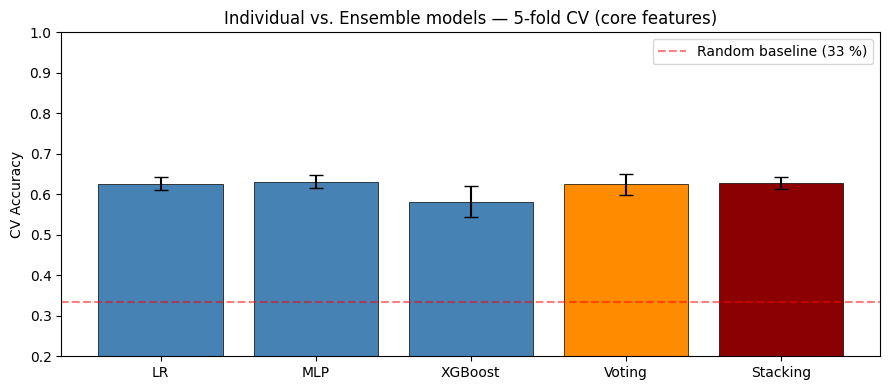

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

names  = list(results.keys())
means  = [v.mean() for v in results.values()]
stds   = [v.std()  for v in results.values()]
colors = ["steelblue"]*3 + ["darkorange", "#8B0000"]

bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, edgecolor="k", linewidth=0.5)
ax.axhline(1/3, color="red", ls="--", alpha=0.5, label="Random baseline (33 %)")
ax.set_ylabel("CV Accuracy")
ax.set_title("Individual vs. Ensemble models — 5-fold CV (core features)")
ax.legend(); ax.set_ylim(0.2, 1.0)
plt.tight_layout(); plt.show()

## Test-set evaluation

In [7]:
for name, model in named:
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:10s}  Test={acc:.3f}")

LR          Test=0.640
MLP         Test=0.650
XGBoost     Test=0.630
Voting      Test=0.650
Stacking    Test=0.650


## Observations

- Soft voting aggregates calibrated probabilities; if base learners disagree strongly it can break ties better than any single model.
- Stacking adds a learned combination layer but risks over-fitting when the dataset is small.
- On the 2-feature core set, class overlap limits all approaches to a similar ceiling; ensemble gains are marginal.
- Extended or engineered features (Notebook 03) are more impactful than ensemble sophistication for this dataset.